In [1]:
# ── Repo-root navigation ─────────────────────────────────────────────────────
# Ensures relative paths (parquet files, cache dirs, figures) resolve correctly
# whether the notebook is run interactively from notebooks/layerN/ or via
# nbconvert from the project root.
import os
from pathlib import Path
_MARKERS = ["fomc_features.parquet", "fomc_corpus_expanded.parquet", ".git"]
_cwd = Path.cwd()
_root = _cwd
while _root != _root.parent:
    if any((_root / m).exists() for m in _MARKERS):
        break
    _root = _root.parent
if _root != _cwd:
    os.chdir(_root)
    print(f"Working directory → {_root}")
else:
    print(f"Working directory  : {_cwd}")

Working directory → /Users/zinuoshi/fomc-vol-study-repo


# FOMC Vol × NLP Backtest Notebook
**Portable — run on any machine that has the two data files below**

## Files to copy to company device
| File | Source | Contains |
|------|--------|---------|
| `fomc_features.parquet` | `fomc_public_pipeline.py` output | NLP features + GK/FRED vol (133 meetings) |
| `fomc_statements.parquet` | same pipeline | Raw statement text (word-bag model) |
| `bloomberg_vol.parquet` | `fomc_vol_study.py` export (see Section 3) | Implied vol, Bloomberg RV, VRP |

## What this notebook does
1. Load NLP features → correlate each feature with realized vol
2. Fit a Ridge regression on NLP features (always runs)
3. If statement text available → word-bag model, word-level correlations
4. If Bloomberg data available → upgrade vol targets, add IV / VRP analysis
5. **Warsh June 2026 backtest**: did the text signal correctly predict vol?

In [2]:

from pathlib import Path

# ── Input files ───────────────────────────────────────────────────────────────
NLP_PARQUET      = Path("fomc_features.parquet")    # REQUIRED
STATEMENTS_PARQUET = Path("fomc_statements.parquet") # for word-bag model

# Bloomberg export from fomc_vol_study.py (set to None to skip)
# Export instructions: at the end of run_fomc_vol_study(), call:
#   results_df.to_parquet("bloomberg_vol.parquet", index=False)
# where results_df has columns: meeting_date, realized_vol, implied_vol, vrp
BLOOMBERG_VOL_PARQUET = None   # e.g. Path("bloomberg_vol.parquet")

# Bloomberg column names (only used if BLOOMBERG_VOL_PARQUET is set)
BBG_DATE_COL = "meeting_date"   # date column in Bloomberg file
BBG_RV_COL   = "realized_vol"   # realized vol (pp annualised)
BBG_IV_COL   = "implied_vol"    # ATM implied vol on FOMC day (optional)
BBG_VRP_COL  = "vrp"            # VRP = IV − RV (optional)

# ── Model settings ────────────────────────────────────────────────────────────
RIDGE_ALPHA       = 50.0   # regularisation strength; increase if overfitting
MIN_WORD_DF       = 5      # word must appear in ≥ N historical meetings
MAX_VOCAB_SIZE    = 1200   # TF-IDF vocabulary cap
TOP_N_WORDS       = 20     # each side of the word-corr bar chart
CV_FOLDS          = 5      # cross-validation folds

# ── Backtest boundary ─────────────────────────────────────────────────────────
# Meetings from this date onwards are "out-of-sample" (Warsh era)
WARSH_START = "2026-06-17"

# ── Output directory ──────────────────────────────────────────────────────────
OUT_DIR = Path("fomc_backtest_output")
OUT_DIR.mkdir(exist_ok=True)

print("Config loaded.")
print(f"  NLP features   : {NLP_PARQUET}")
print(f"  Statement text : {STATEMENTS_PARQUET}")
print(f"  Bloomberg data : {BLOOMBERG_VOL_PARQUET or 'not provided — using public vol'}")
print(f"  Output dir     : {OUT_DIR.resolve()}")

Config loaded.
  NLP features   : fomc_features.parquet
  Statement text : fomc_statements.parquet
  Bloomberg data : not provided — using public vol
  Output dir     : /Users/zinuoshi/fomc-vol-study-repo/fomc_backtest_output


In [3]:

from __future__ import annotations
import re, warnings
from typing import Optional

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import pearsonr
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, KFold, LeaveOneOut
from sklearn.metrics import r2_score, mean_absolute_error
import statsmodels.api as sm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ── Colour palette (matches main pipeline) ───────────────────────────────────
CHAIR_COLORS = {
    "Bernanke": "#1f6091", "Yellen": "#c97a22",
    "Powell": "#2c7a45",   "Warsh":  "#762a83",
}
BUCKET_COLORS = {
    "guidance":    "#2471a3", "uncertainty": "#c0392b",
    "stability":   "#27ae60", "action":      "#8e44ad",
    "neutral":     "#bdc3c7",
}
BUCKET_DISPLAY = {
    "guidance": "Forward guidance", "uncertainty": "Uncertainty / risk",
    "stability": "Stability / confidence", "action": "Rate action / stance",
    "neutral": "Neutral",
}

# ── NLP bucket lexicons (copied from main pipeline for portability) ───────────
LEXICONS = {
    "guidance": {
        "anticipates", "anticipate", "appropriate", "gradual", "gradually",
        "likely", "expects", "expected", "expect", "patience", "patient",
        "flexible", "data", "dependent", "outlook", "forward", "guidance",
        "accommodation", "accommodating", "ongoing", "sustained", "calibrate",
        "measured", "deliberate", "careful", "path", "pace", "judgment",
        "framework", "strategy", "projection", "projections",
    },
    "uncertainty": {
        "uncertain", "uncertainty", "risk", "risks", "challenging", "volatile",
        "volatility", "adverse", "downside", "concern", "concerns", "elevated",
        "headwinds", "tensions", "disruption", "disruptions", "stress",
        "stressed", "deteriorated", "deteriorating", "weaken", "weakened",
        "weakening", "unprecedented", "unclear", "unpredictable", "depends",
        "caution", "cautious", "vigilant", "vigilance", "turbulence",
    },
    "stability": {
        "stable", "stability", "anchored", "sustainable", "balanced", "orderly",
        "resilient", "solid", "steady", "robust", "moderate", "moderating",
        "strength", "strong", "healthy", "improving", "improvement",
        "confident", "confidence", "consistent", "durable", "contained",
        "well", "sound", "healthy", "expanded", "expanding",
    },
    "action": {
        "raise", "raised", "raising", "increase", "increased", "increasing",
        "tighten", "tightening", "restrictive", "firmer", "higher", "hike",
        "normalize", "normalization", "remove", "cut", "cutting", "decrease",
        "decreased", "lower", "lowering", "ease", "easing", "accommodative",
        "reduce", "reducing", "purchase", "purchases", "asset", "quantitative",
        "taper", "tapering", "unwind", "reinvest", "reinvestment",
    },
}

_WC_STOP = {
    "committee", "federal", "open", "market", "reserve", "board", "bank",
    "voting", "voted", "members", "meeting", "fomc", "statement",
    "monetary", "policy", "economic", "economy", "conditions", "inflation",
    "employment", "labor", "growth", "year", "period", "recent", "continue",
    "continued", "remains", "remained", "expects", "expected", "determine",
    "appropriate", "assessed", "current", "levels", "pace", "future",
    "percent", "basis", "points", "funds", "range", "target", "rate", "rates",
    "united", "states", "release", "press", "january", "february", "march",
    "april", "june", "july", "august", "september", "october", "november",
    "december", "also", "will", "that", "this", "from", "with", "have",
    "been", "were", "which", "their", "they", "these", "would", "could",
    "should", "may", "can", "all", "such", "over", "under", "into",
    "about", "when", "some", "our", "the", "and", "for", "not", "but",
    "more", "than", "its", "was", "are", "has", "action",
}


def _clean(text: str) -> str:
    return re.sub(r"\s+", " ", re.sub(r"[^a-z\s]", " ", text.lower())).strip()


def _tokenise(text: str, bigrams: bool = False) -> list[str]:
    words = [w for w in _clean(text).split() if w not in _WC_STOP and len(w) > 3]
    if bigrams:
        words += [f"{a} {b}" for a, b in zip(words, words[1:])]
    return words


def classify_word(word: str) -> str:
    w = word.lower().replace("_", " ")
    for bucket, lexicon in LEXICONS.items():
        if any(seed in w or w in seed for seed in lexicon):
            return bucket
    return "neutral"


def savefig(fig: plt.Figure, name: str) -> None:
    path = OUT_DIR / f"{name}.png"
    from IPython.display import display as _d
    _d(fig)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Saved → {path}")
    plt.close(fig)


print("Imports OK.")

Imports OK.


In [4]:
# fomc_features.parquet must be present (generated by fomc_public_pipeline.py)

assert NLP_PARQUET.exists(), (
    f"Missing {NLP_PARQUET}. Run fomc_public_pipeline.py first and copy "
    "fomc_features.parquet to this directory."
)

nlp = pd.read_parquet(NLP_PARQUET)
nlp["meeting_date"] = pd.to_datetime(nlp["meeting_date"])
nlp = nlp.sort_values("meeting_date").reset_index(drop=True)

print(f"NLP features loaded: {nlp.shape}")
print(f"  Date range: {nlp['meeting_date'].min().date()} → {nlp['meeting_date'].max().date()}")
print(f"  Chairs: {dict(nlp['chair'].value_counts())}")
print(f"\nColumns:")
for col in nlp.columns:
    n_valid = nlp[col].notna().sum()
    print(f"  {col:35s}  {n_valid:3d} / {len(nlp)} non-null")

NLP features loaded: (133, 36)
  Date range: 2010-01-27 → 2026-06-17
  Chairs: {'Powell': 67, 'Bernanke': 33, 'Yellen': 32, 'Warsh': 1}

Columns:
  meeting_date                         133 / 133 non-null
  chair                                133 / 133 non-null
  presser_available                    133 / 133 non-null
  word_count                           133 / 133 non-null
  word_count_change                    131 / 133 non-null
  word_count_zscore                    131 / 133 non-null
  word_count_pct_rank                  133 / 133 non-null
  novelty_prev                         132 / 133 non-null
  novelty_window                       132 / 133 non-null
  novelty_zscore                       131 / 133 non-null
  guidance_density                     133 / 133 non-null
  guidance_presence                    133 / 133 non-null
  guidance_change                      131 / 133 non-null
  uncertainty_density                  133 / 133 non-null
  weak_modal_density                   133

In [5]:
# On company device: set BLOOMBERG_VOL_PARQUET in Section 0 CONFIG and point to
# the Parquet/CSV export from fomc_vol_study.py.
#
# Export snippet to add at the end of run_fomc_vol_study() in fomc_vol_study.py:
# ─────────────────────────────────────────────────────────────────────────────
#   bbg_export = pl.DataFrame({
#       "meeting_date": fomc_dates,           # list of date strings or datetime
#       "implied_vol":  atm_iv_series,        # ATM IV on FOMC day (pp ann.)
#       "realized_vol": rv_series,            # realized vol to match (pp ann.)
#       "vrp":          vrp_series,           # implied − realized
#   })
#   bbg_export.write_parquet("bloomberg_vol.parquet")
# ─────────────────────────────────────────────────────────────────────────────

bbg: Optional[pd.DataFrame] = None
if BLOOMBERG_VOL_PARQUET is not None:
    p = Path(BLOOMBERG_VOL_PARQUET)
    if p.exists():
        if p.suffix == ".csv":
            bbg = pd.read_csv(p)
        else:
            bbg = pd.read_parquet(p)
        bbg[BBG_DATE_COL] = pd.to_datetime(bbg[BBG_DATE_COL])
        bbg = bbg.rename(columns={BBG_DATE_COL: "meeting_date"})
        print(f"Bloomberg data loaded: {bbg.shape}  cols={list(bbg.columns)}")
    else:
        print(f"WARNING: BLOOMBERG_VOL_PARQUET set but {p} not found — using public vol.")

# ── Pick vol target columns ───────────────────────────────────────────────────
# Priority: Bloomberg RV > public GK vol > FRED forward RV

if bbg is not None and BBG_RV_COL in bbg.columns:
    # Merge Bloomberg vol into nlp frame
    bbg_slim = bbg[["meeting_date"] + [c for c in [BBG_RV_COL, BBG_IV_COL, BBG_VRP_COL]
                                        if c in bbg.columns]].copy()
    nlp = nlp.merge(bbg_slim, on="meeting_date", how="left")
    PRIMARY_VOL   = BBG_RV_COL
    SECONDARY_VOL = BBG_VRP_COL if BBG_VRP_COL in nlp.columns else None
    IV_COL        = BBG_IV_COL  if BBG_IV_COL  in nlp.columns else None
    print(f"\nUsing Bloomberg vol: primary={PRIMARY_VOL}  IV={IV_COL}  VRP={SECONDARY_VOL}")
else:
    PRIMARY_VOL   = "gk_vol_10y"        if "gk_vol_10y"        in nlp.columns else None
    SECONDARY_VOL = "rv_yield_10y_5d"   if "rv_yield_10y_5d"   in nlp.columns else None
    IV_COL        = None
    print(f"\nUsing public vol: primary={PRIMARY_VOL}  secondary={SECONDARY_VOL}")

if PRIMARY_VOL is None:
    raise RuntimeError("No vol column found. Check parquet contents.")

# ── Train / test split ────────────────────────────────────────────────────────
warsh_cutoff = pd.Timestamp(WARSH_START)
train_mask   = nlp["meeting_date"] < warsh_cutoff
test_mask    = nlp["meeting_date"] >= warsh_cutoff

nlp_train = nlp[train_mask].copy()
nlp_test  = nlp[test_mask].copy()

print(f"\nTrain (historical): {train_mask.sum()} meetings")
print(f"Test  (Warsh OOS) : {test_mask.sum()} meetings")
print(f"Primary vol non-null (train): {nlp_train[PRIMARY_VOL].notna().sum()}")


Using public vol: primary=gk_vol_10y  secondary=rv_yield_10y_5d

Train (historical): 132 meetings
Test  (Warsh OOS) : 1 meetings
Primary vol non-null (train): 131


In [6]:
# fomc_statements.parquet is generated alongside fomc_features.parquet

stmt_df: Optional[pd.DataFrame] = None
if STATEMENTS_PARQUET.exists():
    stmt_df = pd.read_parquet(STATEMENTS_PARQUET)
    stmt_df["meeting_date"] = pd.to_datetime(stmt_df["meeting_date"])
    print(f"Statement text loaded: {stmt_df.shape}")
    print(f"  Sample (Warsh):")
    warsh_row = stmt_df[stmt_df["meeting_date"] >= warsh_cutoff]
    if not warsh_row.empty:
        print("  " + warsh_row.iloc[-1]["text"][:300] + "…")
else:
    print(f"WARNING: {STATEMENTS_PARQUET} not found — word-bag model will be skipped.")
    print("Copy fomc_statements.parquet alongside fomc_features.parquet.")

Statement text loaded: (133, 3)
  Sample (Warsh):
  The Federal Open Market Committee approved the following statement for release by a 12 â 0 vote: The Committee decided to maintain the target range for the federal funds rate at 3-1/2 to 3-3/4 percent, in support of the Federal Reserve's dual mandate. The Committee reaffirmed its policy of maintai…


In [7]:

NLP_FEATURES = [c for c in [
    "word_count_zscore", "novelty_prev", "novelty_window",
    "guidance_change", "uncertainty_density", "disagree_density",
    "polarity_hd", "presser_flag",
] if c in nlp.columns]

print(f"NLP features available: {NLP_FEATURES}")
print(f"\nVol stats (train, {PRIMARY_VOL}):")
y_train_desc = nlp_train[PRIMARY_VOL].dropna().describe()
print(y_train_desc.to_string())

if not nlp_test.empty:
    print(f"\nWarsh meeting(s):")
    cols_to_show = ["meeting_date", "chair"] + NLP_FEATURES + [PRIMARY_VOL]
    cols_to_show = [c for c in cols_to_show if c in nlp_test.columns]
    print(nlp_test[cols_to_show].to_string(index=False))

NLP features available: ['word_count_zscore', 'novelty_prev', 'novelty_window', 'guidance_change', 'uncertainty_density', 'disagree_density', 'polarity_hd']

Vol stats (train, gk_vol_10y):
count    131.000000
mean      32.328624
std       25.218177
min        7.776589
25%       18.934984
50%       28.195110
75%       39.494734
max      254.797964

Warsh meeting(s):
meeting_date chair  word_count_zscore  novelty_prev  novelty_window  guidance_change  uncertainty_density  disagree_density  polarity_hd  gk_vol_10y
  2026-06-17 Warsh          -4.777459      0.646787        0.661623        -0.582051             0.929547               0.0    -0.006452   12.605491


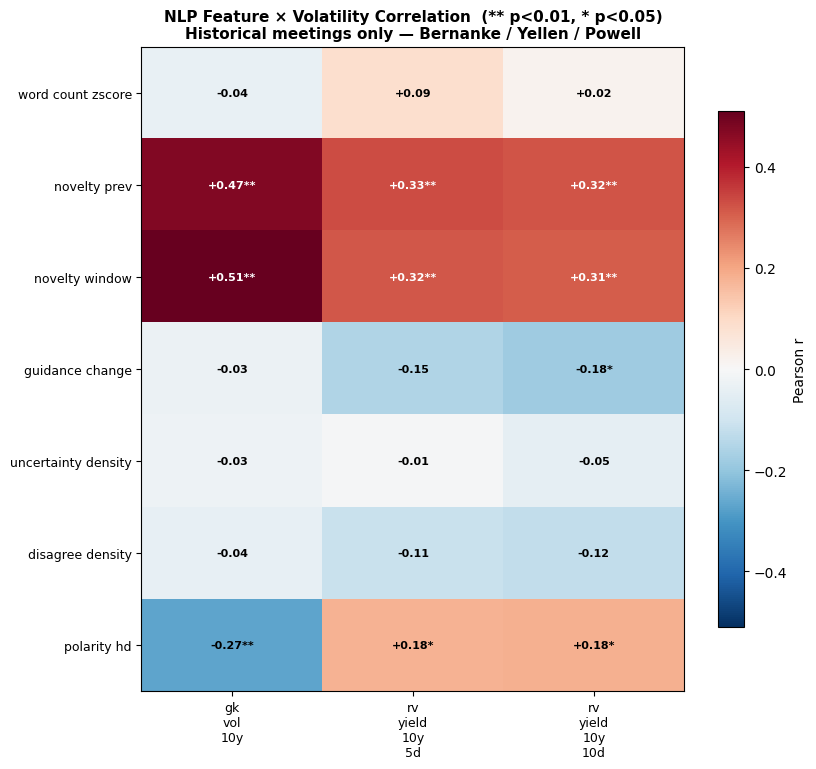

  Saved → fomc_backtest_output/fig1_feature_vol_heatmap.png


In [8]:
# Pearson r between each NLP feature and each vol metric (historical only)

def plot_feature_heatmap(df: pd.DataFrame,
                         feature_cols: list[str],
                         vol_cols: list[str]) -> plt.Figure:
    vol_cols = [v for v in vol_cols if v in df.columns]
    mat = pd.DataFrame(index=feature_cols, columns=vol_cols, dtype=float)
    pmat = pd.DataFrame(index=feature_cols, columns=vol_cols, dtype=float)

    for f in feature_cols:
        for v in vol_cols:
            valid = df[[f, v]].dropna()
            if len(valid) >= 10:
                r, p = pearsonr(valid[f], valid[v])
                mat.loc[f, v] = r
                pmat.loc[f, v] = p

    fig, ax = plt.subplots(figsize=(max(6, len(vol_cols) * 2.8), len(feature_cols) * 0.9 + 1.5))
    vals = mat.values.astype(float)
    vabs = np.nanmax(np.abs(vals))
    im   = ax.imshow(vals, cmap="RdBu_r", vmin=-vabs, vmax=vabs, aspect="auto")
    plt.colorbar(im, ax=ax, label="Pearson r", shrink=0.8)

    ax.set_xticks(range(len(vol_cols)))
    ax.set_xticklabels([c.replace("_", "\n") for c in vol_cols], fontsize=9)
    ax.set_yticks(range(len(feature_cols)))
    ax.set_yticklabels([c.replace("_", " ") for c in feature_cols], fontsize=9)

    for i, f in enumerate(feature_cols):
        for j, v in enumerate(vol_cols):
            val = mat.loc[f, v]
            if not np.isnan(float(val)):
                sig = "**" if float(pmat.loc[f, v]) < 0.01 else ("*" if float(pmat.loc[f, v]) < 0.05 else "")
                ax.text(j, i, f"{float(val):+.2f}{sig}", ha="center", va="center",
                        fontsize=8, fontweight="bold",
                        color="white" if abs(float(val)) > 0.3 else "black")

    ax.set_title("NLP Feature × Volatility Correlation  (** p<0.01, * p<0.05)\n"
                 "Historical meetings only — Bernanke / Yellen / Powell",
                 fontsize=11, fontweight="bold")
    fig.tight_layout()
    savefig(fig, "fig1_feature_vol_heatmap")
    return fig


_vol_cols_for_heatmap = list(dict.fromkeys(
    c for c in [PRIMARY_VOL, SECONDARY_VOL, IV_COL, "rv_yield_10y_5d", "rv_yield_10y_10d"]
    if c is not None and c in nlp_train.columns
))
fig1 = plot_feature_heatmap(nlp_train, NLP_FEATURES, _vol_cols_for_heatmap)
plt.show()

In [9]:
# Trains a regularised regression on the 6-8 NLP features.
# Uses leave-one-out CV for historical predictions (N≈130 makes 5-fold noisy).
# This model always runs — no raw text needed.

def fit_nlp_feature_model(df_train: pd.DataFrame,
                           feature_cols: list[str],
                           y_col: str,
                           alpha: float = 1.0) -> tuple:
    """
    Ridge regression on NLP features with leave-one-out cross-validation.
    Returns (model, scaler, cv_preds, cv_r2, cv_mae).
    """
    valid = df_train[[y_col] + feature_cols].dropna()
    Xv    = valid[feature_cols].values
    yv    = valid[y_col].values

    scaler = StandardScaler()
    Xs     = scaler.fit_transform(Xv)

    model  = Ridge(alpha=alpha)
    loo    = LeaveOneOut()
    y_cv   = cross_val_predict(model, Xs, yv, cv=loo)

    cv_r2  = r2_score(yv, y_cv)
    cv_mae = mean_absolute_error(yv, y_cv)

    model.fit(Xs, yv)
    return model, scaler, pd.Series(y_cv, index=valid.index), cv_r2, cv_mae, valid


def nlp_predict(model, scaler, df: pd.DataFrame,
                feature_cols: list[str]) -> pd.Series:
    """Predict vol for rows in df using fitted NLP feature model."""
    avail = df[feature_cols].copy()
    # Fill any missing features with training mean (0 after scaling)
    for c in feature_cols:
        if avail[c].isna().any():
            avail[c] = avail[c].fillna(0.0)
    Xs = scaler.transform(avail.values)
    return pd.Series(model.predict(Xs), index=df.index)


def print_nlp_model_summary(model, feature_cols, cv_r2, cv_mae):
    """Print coefficient table for the NLP feature model."""
    print(f"\n  Ridge NLP Model (α={model.alpha})  LOO CV R²={cv_r2:.3f}  MAE={cv_mae:.2f}pp")
    print(f"  {'Feature':30s}  {'Coef (scaled)':>14s}")
    print(f"  {'─'*48}")
    for f, c in sorted(zip(feature_cols, model.coef_), key=lambda x: abs(x[1]), reverse=True):
        bar = "█" * int(abs(c) / max(abs(model.coef_)) * 15)
        print(f"  {f:30s}  {c:>+14.4f}  {bar}")


# Ridge alpha=1.0 is appropriate for small NLP feature set (8 features)
_nlp_model, _nlp_scaler, _nlp_cv_preds, _nlp_cv_r2, _nlp_cv_mae, _nlp_valid = \
    fit_nlp_feature_model(nlp_train, NLP_FEATURES, PRIMARY_VOL, alpha=1.0)

print_nlp_model_summary(_nlp_model, NLP_FEATURES, _nlp_cv_r2, _nlp_cv_mae)

# Warsh prediction from NLP feature model
_nlp_warsh_pred = None
if not nlp_test.empty:
    _nlp_warsh_pred_s = nlp_predict(_nlp_model, _nlp_scaler, nlp_test, NLP_FEATURES)
    _nlp_warsh_pred   = float(_nlp_warsh_pred_s.iloc[0])
    print(f"\n  Warsh prediction (NLP features only): {_nlp_warsh_pred:.2f} pp")


  Ridge NLP Model (α=1.0)  LOO CV R²=0.060  MAE=15.33pp
  Feature                          Coef (scaled)
  ────────────────────────────────────────────────
  novelty_window                        +10.4438  ███████████████
  polarity_hd                            -6.7071  █████████
  novelty_prev                           +2.4417  ███
  disagree_density                       -1.5320  ██
  uncertainty_density                    +0.8297  █
  guidance_change                        -0.2361  
  word_count_zscore                      -0.2101  

  Warsh prediction (NLP features only): 88.68 pp


In [10]:
# Full OLS table with Newey-West standard errors, printed for desk review

def hac_table(df: pd.DataFrame, y_col: str, x_cols: list[str],
              hac_lags: int = 8) -> None:
    valid = df[[y_col] + x_cols].dropna()
    X     = sm.add_constant(valid[x_cols].values.astype(float))
    y     = valid[y_col].values
    ols   = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    param_names = ["const"] + x_cols
    print(f"\nHAC Regression: {y_col}  (Newey-West, lags={hac_lags})")
    print(f"  N={len(valid)}  R²={ols.rsquared:.3f}  adj-R²={ols.rsquared_adj:.3f}")
    print(f"  {'Variable':30s}  {'Coef':>10s}  {'t-stat':>8s}  {'p-val':>8s}  {'sig':>4s}")
    print(f"  {'─'*64}")
    for name, coef, pval, tstat in zip(param_names,
                                        ols.params, ols.pvalues, ols.tvalues):
        sig = "***" if pval < 0.01 else ("**" if pval < 0.05 else ("*" if pval < 0.1 else ""))
        print(f"  {name:30s}  {coef:>10.4f}  {tstat:>8.2f}  {pval:>8.4f}  {sig:>4s}")

hac_table(nlp_train, PRIMARY_VOL, NLP_FEATURES, hac_lags=8)


HAC Regression: gk_vol_10y  (Newey-West, lags=8)
  N=129  R²=0.339  adj-R²=0.300
  Variable                              Coef    t-stat     p-val   sig
  ────────────────────────────────────────────────────────────────
  const                              -2.9311     -0.23    0.8215      
  word_count_zscore                  -0.0821     -0.07    0.9481      
  novelty_prev                       21.6523      0.54    0.5865      
  novelty_window                    100.1345      2.40    0.0163    **
  guidance_change                    -0.6876     -0.11    0.9095      
  uncertainty_density                 0.7378      0.69    0.4882      
  disagree_density                  -24.6102     -1.27    0.2035      
  polarity_hd                     -1534.2464     -2.22    0.0261    **


In [11]:

_word_cv_preds    = None
_word_warsh_pred  = None
_corr_df          = None
_word_vec         = None
_word_model       = None
_word_scaler      = None
_word_contrib     = {}

if stmt_df is not None:
    # ── Build TF-IDF matrix ───────────────────────────────────────────────────
    merged_text = (nlp[["meeting_date", "chair"]]
                   .merge(stmt_df[["meeting_date", "text"]], on="meeting_date", how="left"))
    merged_text = merged_text.merge(nlp[[PRIMARY_VOL, "meeting_date"]], on="meeting_date", how="left")

    train_text = merged_text[merged_text["meeting_date"] < warsh_cutoff].copy()
    test_text  = merged_text[merged_text["meeting_date"] >= warsh_cutoff].copy()

    _word_vec = TfidfVectorizer(
        preprocessor=_clean,
        tokenizer=lambda t: _tokenise(t, bigrams=True),
        token_pattern=None,
        min_df=MIN_WORD_DF,
        max_features=MAX_VOCAB_SIZE,
        sublinear_tf=True,
    )
    X_train_sp = _word_vec.fit_transform(train_text["text"].fillna(""))
    X_test_sp  = _word_vec.transform(test_text["text"].fillna(""))
    X_train_arr = X_train_sp.toarray()
    X_test_arr  = X_test_sp.toarray()
    y_train_arr = train_text[PRIMARY_VOL].values

    # ── Word-vol correlations ─────────────────────────────────────────────────
    valid_mask = ~np.isnan(y_train_arr)
    rows = []
    for j, word in enumerate(_word_vec.get_feature_names_out()):
        x = X_train_arr[valid_mask, j]
        if (x > 0).sum() < MIN_WORD_DF:
            continue
        r, p = pearsonr(x, y_train_arr[valid_mask])
        if not np.isnan(r):
            rows.append({"word": word, "r": r, "p": p,
                         "bucket": classify_word(word),
                         "n": int((x > 0).sum())})
    _corr_df = (pd.DataFrame(rows)
                  .assign(abs_r=lambda d: d["r"].abs())
                  .sort_values("abs_r", ascending=False)
                  .reset_index(drop=True))

    # ── Ridge word model ──────────────────────────────────────────────────────
    valid_idx = np.where(valid_mask)[0]
    Xv = X_train_arr[valid_idx]
    yv = y_train_arr[valid_idx]

    _word_scaler = StandardScaler(with_mean=False)
    Xvs = _word_scaler.fit_transform(Xv)

    _word_model = Ridge(alpha=RIDGE_ALPHA)
    cv          = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
    _word_cv_raw = cross_val_predict(_word_model, Xvs, yv, cv=cv)
    _word_cv_r2  = r2_score(yv, _word_cv_raw)
    _word_cv_mae = mean_absolute_error(yv, _word_cv_raw)
    _word_model.fit(Xvs, yv)
    _word_cv_preds = pd.Series(_word_cv_raw, index=train_text.index[valid_idx])

    print(f"\nWord-bag Ridge (α={RIDGE_ALPHA})  {CV_FOLDS}-fold CV  "
          f"R²={_word_cv_r2:.3f}  MAE={_word_cv_mae:.2f}pp")

    # Warsh word prediction
    if len(test_text):
        Xts = _word_scaler.transform(X_test_arr)
        preds = _word_model.predict(Xts)
        _word_warsh_pred = float(preds[0])

        # Top contributing words for Warsh's statement
        feat_vals = X_test_arr[0]
        contribs  = _word_model.coef_ / _word_scaler.scale_ * feat_vals
        _word_contrib = {w: float(c) for w, c in
                         zip(_word_vec.get_feature_names_out(), contribs) if feat_vals[list(
                             _word_vec.get_feature_names_out()).index(w)] > 0}
        _word_contrib = dict(sorted(_word_contrib.items(), key=lambda x: abs(x[1]), reverse=True)[:20])
        print(f"  Warsh word-bag prediction: {_word_warsh_pred:.2f} pp")
else:
    print("Word-bag model skipped (no statement text file).")
    print(f"Copy fomc_statements.parquet to {Path.cwd()} to enable it.")


Word-bag Ridge (α=50.0)  5-fold CV  R²=0.217  MAE=12.75pp


  Warsh word-bag prediction: 60.44 pp


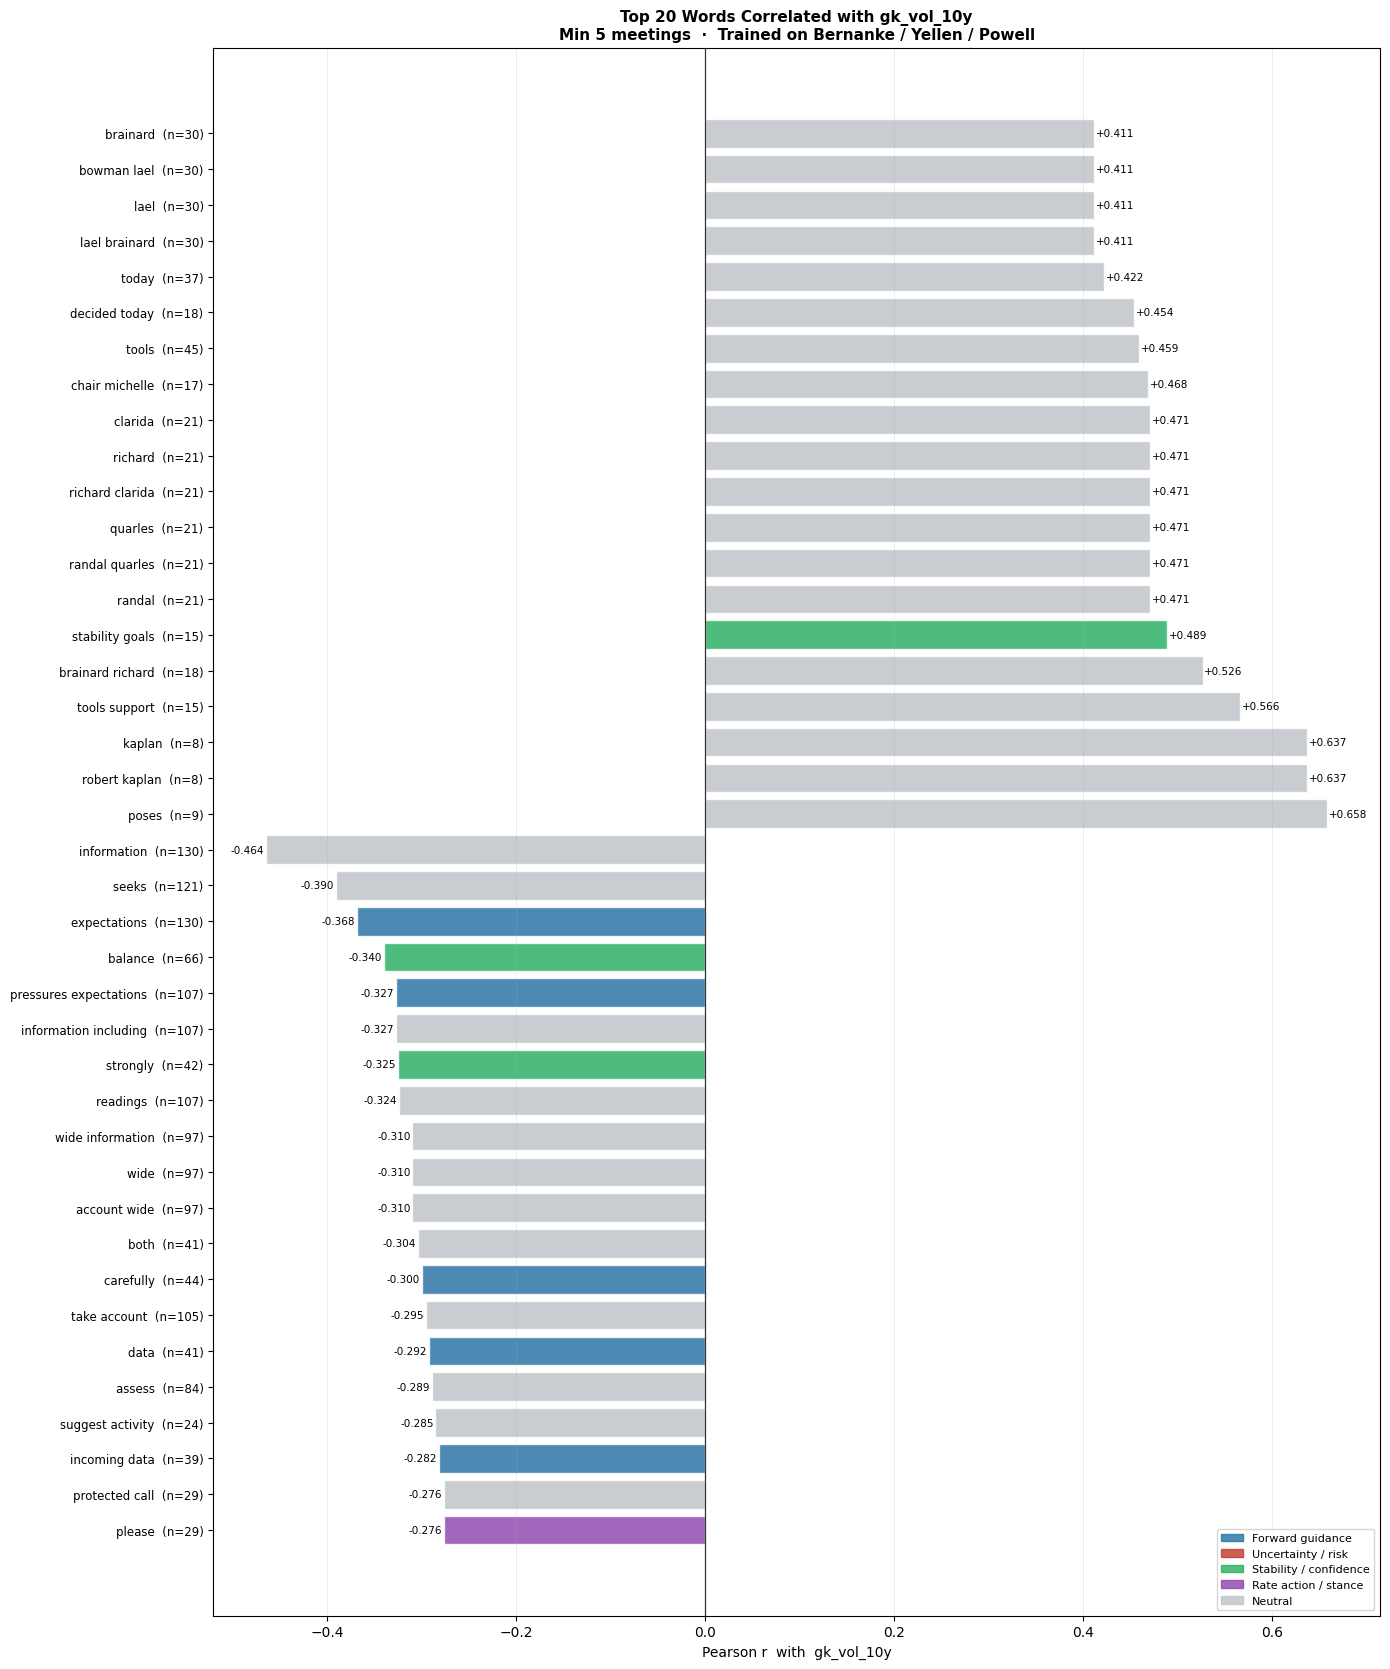

  Saved → fomc_backtest_output/fig2_word_vol_corr.png

Top 20 HIGH-vol words:
            word        r            p    bucket  n
           poses 0.657900 1.373290e-17   neutral  9
   robert kaplan 0.637043 2.847452e-16   neutral  8
          kaplan 0.637043 2.847452e-16   neutral  8
   tools support 0.565574 1.943373e-12   neutral 15
brainard richard 0.526272 1.076993e-10   neutral 18
 stability goals 0.488815 3.149005e-09 stability 15
          randal 0.470921 1.375554e-08   neutral 21
  randal quarles 0.470921 1.375554e-08   neutral 21
         quarles 0.470921 1.375554e-08   neutral 21
 richard clarida 0.470921 1.375554e-08   neutral 21
         richard 0.470921 1.375554e-08   neutral 21
         clarida 0.470921 1.375554e-08   neutral 21
  chair michelle 0.468438 1.676796e-08   neutral 17
           tools 0.459350 3.415241e-08   neutral 45
   decided today 0.453832 5.207973e-08   neutral 18
           today 0.422059 5.139977e-07   neutral 37
   lael brainard 0.411275 1.061643e-06

In [12]:

def plot_word_corr_bar(corr_df: pd.DataFrame,
                       vol_label: str,
                       top_n: int = 20) -> Optional[plt.Figure]:
    if corr_df is None or corr_df.empty:
        print("Skipped (no word correlations).")
        return None

    pos = corr_df[corr_df["r"] > 0].head(top_n)
    neg = corr_df[corr_df["r"] < 0].head(top_n)
    plot_df = pd.concat([neg.iloc[::-1], pos]).reset_index(drop=True)

    colors = [BUCKET_COLORS.get(b, "#bdc3c7") for b in plot_df["bucket"]]
    y_pos  = np.arange(len(plot_df))

    fig, ax = plt.subplots(figsize=(14, max(8, len(plot_df) * 0.42)))
    bars = ax.barh(y_pos, plot_df["r"], color=colors, alpha=0.82, edgecolor="white")
    ax.axvline(0, color="#333", lw=0.9)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f"{r['word']}  (n={r['n']})" for _, r in plot_df.iterrows()],
                       fontsize=8.5)
    ax.set_xlabel(f"Pearson r  with  {vol_label}", fontsize=10)
    ax.set_title(
        f"Top {top_n} Words Correlated with {vol_label}\n"
        f"Min {MIN_WORD_DF} meetings  ·  Trained on Bernanke / Yellen / Powell",
        fontsize=11, fontweight="bold")

    for bar, r_val in zip(bars, plot_df["r"]):
        x = bar.get_width()
        ax.text(x + (0.002 if x >= 0 else -0.002),
                bar.get_y() + bar.get_height() / 2,
                f"{r_val:+.3f}", va="center",
                ha="left" if x >= 0 else "right", fontsize=7.5)

    handles = [mpatches.Patch(color=BUCKET_COLORS[b], alpha=0.8, label=BUCKET_DISPLAY[b])
               for b in ["guidance", "uncertainty", "stability", "action", "neutral"]]
    ax.legend(handles=handles, fontsize=8, loc="lower right")
    ax.grid(axis="x", lw=0.4, alpha=0.4)
    fig.tight_layout()
    savefig(fig, "fig2_word_vol_corr")
    return fig


fig2 = plot_word_corr_bar(_corr_df, vol_label=PRIMARY_VOL, top_n=TOP_N_WORDS)
if fig2:
    plt.show()

if _corr_df is not None and not _corr_df.empty:
    print(f"\nTop {TOP_N_WORDS} HIGH-vol words:")
    print(_corr_df[_corr_df["r"] > 0].head(TOP_N_WORDS)[
        ["word", "r", "p", "bucket", "n"]].to_string(index=False))
    print(f"\nTop {TOP_N_WORDS} LOW-vol words:")
    print(_corr_df[_corr_df["r"] < 0].head(TOP_N_WORDS)[
        ["word", "r", "p", "bucket", "n"]].to_string(index=False))

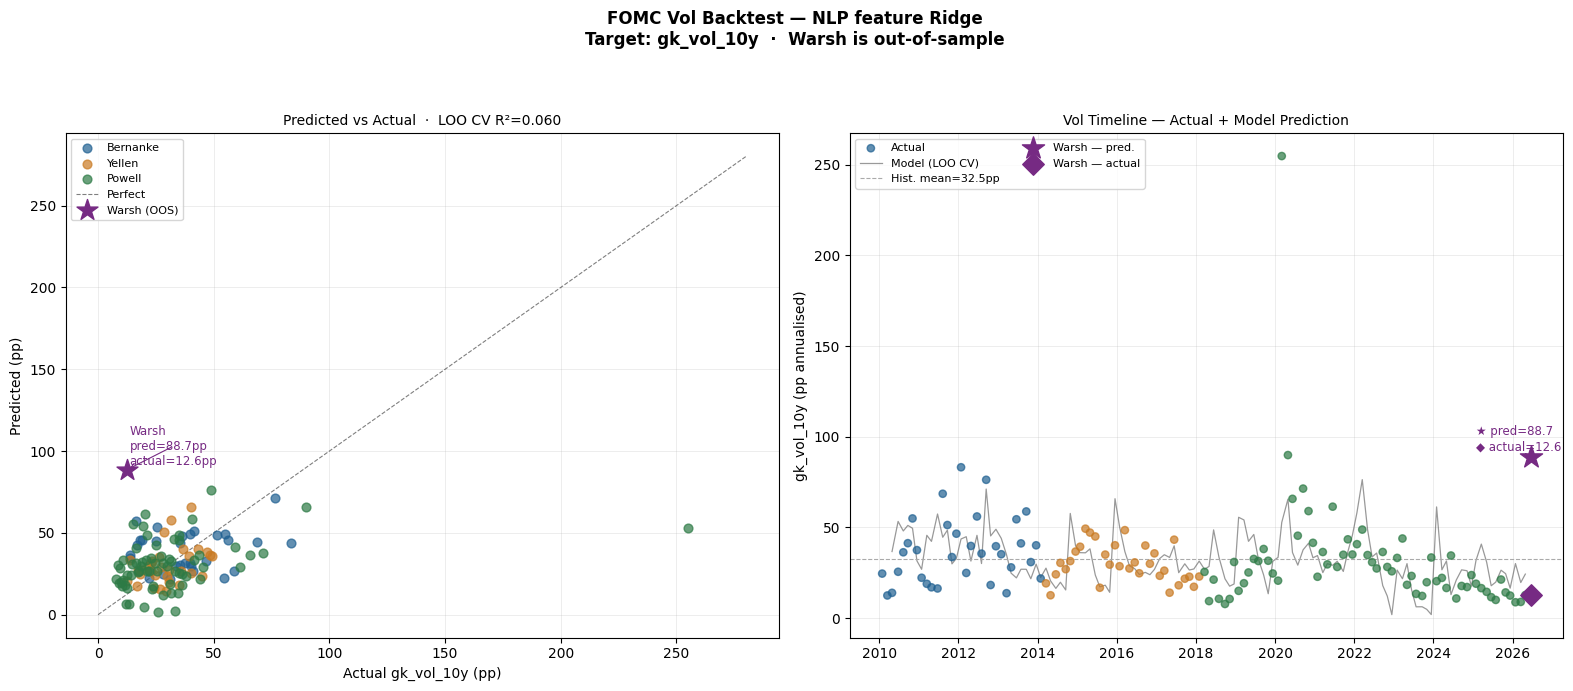

  Saved → fomc_backtest_output/fig3_nlp_backtest_scatter.png


In [13]:

def plot_backtest_scatter(cv_preds: pd.Series,
                          y_actual: pd.Series,
                          chair_series: pd.Series,
                          warsh_preds: dict,
                          vol_label: str,
                          model_label: str = "NLP feature model",
                          cv_r2: float = 0.0) -> plt.Figure:
    """
    Left: predicted vs actual scatter (historical, LOO CV), colour = chair.
    Right: vol timeline, actual dots + model line, Warsh starred.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f"FOMC Vol Backtest — {model_label}\n"
                 f"Target: {vol_label}  ·  Warsh is out-of-sample",
                 fontsize=12, fontweight="bold")

    # ── Left: scatter ────────────────────────────────────────────────────────
    common = cv_preds.index.intersection(y_actual.dropna().index)
    if len(common):
        yp = cv_preds.loc[common]
        ya = y_actual.loc[common]
        ch = chair_series.loc[common] if hasattr(chair_series, 'loc') else pd.Series("Unknown", index=common)
        for chair in ["Bernanke", "Yellen", "Powell"]:
            m = ch == chair
            if m.any():
                ax1.scatter(ya[m], yp[m], color=CHAIR_COLORS.get(chair, "#888"),
                            alpha=0.7, s=40, label=chair, zorder=3)
        lim = max(ya.max(), yp.max()) * 1.1
        ax1.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.5, label="Perfect")

    for date, pred_val in warsh_preds.items():
        actual = float(y_actual.get(date, np.nan)) if hasattr(y_actual, 'get') else np.nan
        if not np.isnan(actual):
            ax1.scatter([actual], [pred_val],
                        color=CHAIR_COLORS.get("Warsh", "#762a83"),
                        s=250, marker="*", zorder=6, label="Warsh (OOS)")
            ax1.annotate(
                f"Warsh\npred={pred_val:.1f}pp\nactual={actual:.1f}pp",
                xy=(actual, pred_val),
                xytext=(actual + 1, pred_val + 3),
                fontsize=8.5, color=CHAIR_COLORS.get("Warsh", "#762a83"),
                arrowprops=dict(arrowstyle="->", color="#762a83", lw=0.8),
            )

    ax1.set_xlabel(f"Actual {vol_label} (pp)", fontsize=10)
    ax1.set_ylabel("Predicted (pp)", fontsize=10)
    ax1.set_title(f"Predicted vs Actual  ·  LOO CV R²={cv_r2:.3f}", fontsize=10)
    ax1.legend(fontsize=8)
    ax1.grid(lw=0.4, alpha=0.4)

    # ── Right: timeline ───────────────────────────────────────────────────────
    dates_all = y_actual.dropna().index
    if len(dates_all):
        ch_all = chair_series.loc[dates_all] if hasattr(chair_series, 'loc') else pd.Series("Unknown", index=dates_all)
        ax2.scatter(dates_all, y_actual.loc[dates_all],
                    color=[CHAIR_COLORS.get(str(c), "#888") for c in ch_all],
                    s=28, alpha=0.7, zorder=3, label="Actual")

    common_t = cv_preds.index.intersection(y_actual.dropna().index)
    if len(common_t):
        sorted_t = sorted(common_t)
        ax2.plot(sorted_t, [cv_preds.loc[d] for d in sorted_t],
                 color="#555", lw=0.9, alpha=0.6, label="Model (LOO CV)")

    # Historical mean band
    if len(common):
        hmean = ya.mean()
        ax2.axhline(hmean, color="#aaa", lw=0.8, linestyle="--",
                    label=f"Hist. mean={hmean:.1f}pp")

    for date, pred_val in warsh_preds.items():
        actual = float(y_actual.get(date, np.nan)) if hasattr(y_actual, 'get') else np.nan
        ax2.scatter([date], [pred_val],
                    color=CHAIR_COLORS.get("Warsh", "#762a83"),
                    s=280, marker="*", zorder=7, label="Warsh — pred.")
        if not np.isnan(actual):
            ax2.scatter([date], [actual],
                        color=CHAIR_COLORS.get("Warsh", "#762a83"),
                        s=120, marker="D", zorder=7, label="Warsh — actual")
            ax2.annotate(
                f"★ pred={pred_val:.1f}\n◆ actual={actual:.1f}",
                xy=(date, max(pred_val, actual)),
                xytext=(date - pd.Timedelta(days=500),
                        max(pred_val, actual) + 4),
                fontsize=8.5, color=CHAIR_COLORS.get("Warsh", "#762a83"),
                arrowprops=dict(arrowstyle="->", color="#762a83", lw=0.8),
            )

    ax2.set_ylabel(f"{vol_label} (pp annualised)", fontsize=10)
    ax2.set_title("Vol Timeline — Actual + Model Prediction", fontsize=10)
    ax2.legend(fontsize=8, ncol=2)
    ax2.grid(lw=0.4, alpha=0.4)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    return fig


# Build common inputs for the scatter function
_y_actual_s  = nlp.set_index("meeting_date")[PRIMARY_VOL]
_chair_s     = nlp.set_index("meeting_date")["chair"]

_nlp_warsh_preds_dict = {}
if not nlp_test.empty and _nlp_warsh_pred is not None:
    for dt in nlp_test["meeting_date"]:
        _nlp_warsh_preds_dict[dt] = float(nlp_predict(
            _nlp_model, _nlp_scaler,
            nlp_test[nlp_test["meeting_date"] == dt], NLP_FEATURES).iloc[0])

fig3 = plot_backtest_scatter(
    _nlp_cv_preds.set_axis(
        _nlp_valid.index.map(lambda i: nlp_train.iloc[i]["meeting_date"]
                             if isinstance(i, int) else nlp_train.loc[i, "meeting_date"])
    ) if hasattr(_nlp_valid, 'index') else _nlp_cv_preds,
    _y_actual_s,
    _chair_s,
    _nlp_warsh_preds_dict,
    vol_label=PRIMARY_VOL,
    model_label="NLP feature Ridge",
    cv_r2=_nlp_cv_r2,
)
savefig(fig3, "fig3_nlp_backtest_scatter")
plt.show()

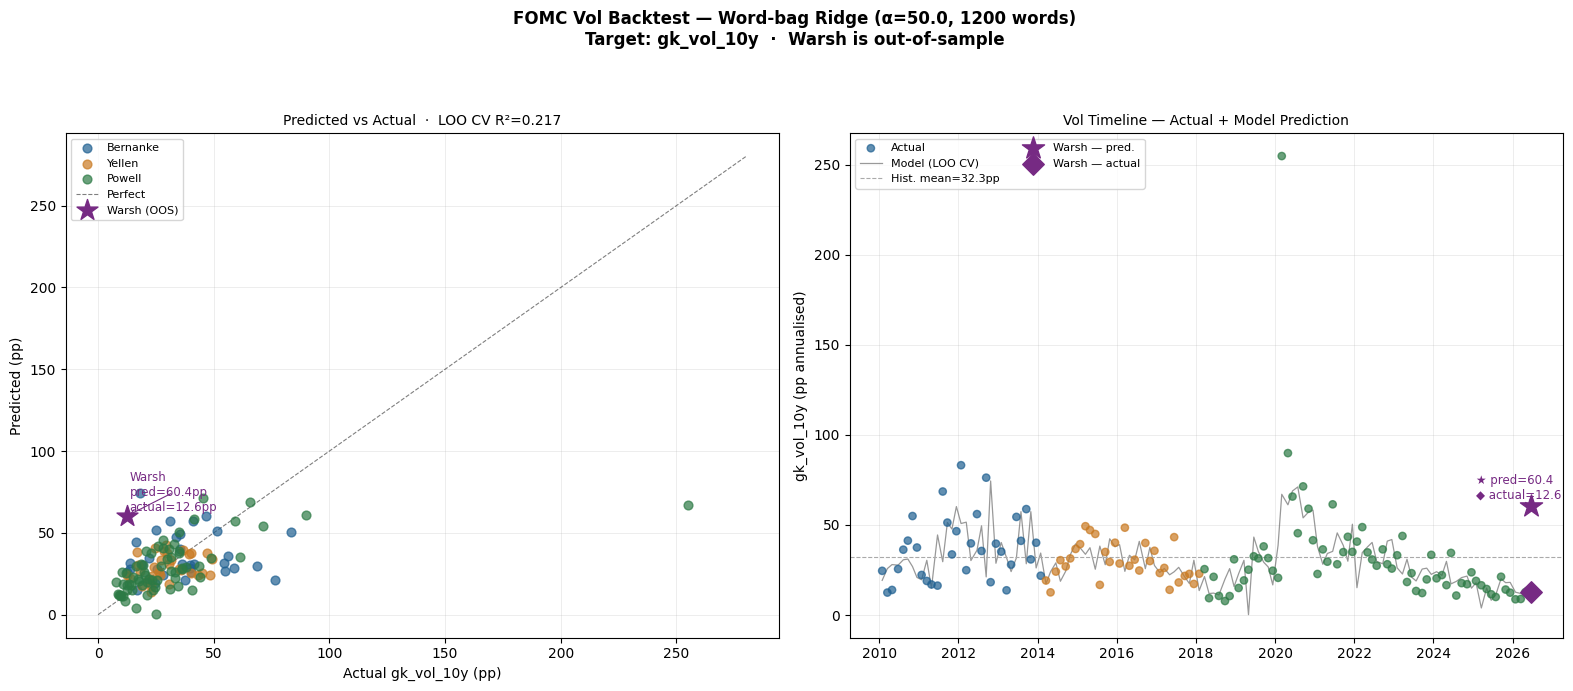

  Saved → fomc_backtest_output/fig4_wordbag_backtest_scatter.png


In [14]:

if _word_cv_preds is not None and stmt_df is not None:
    merged_text = (nlp[["meeting_date", "chair"]]
                   .merge(stmt_df[["meeting_date", "text"]], on="meeting_date", how="left"))
    merged_text = merged_text.merge(nlp[[PRIMARY_VOL, "meeting_date"]], on="meeting_date", how="left")
    train_text  = merged_text[merged_text["meeting_date"] < warsh_cutoff]

    valid_mask  = ~train_text[PRIMARY_VOL].isna().values
    _word_cv_dates = train_text[valid_mask]["meeting_date"].values
    _word_cv_s     = pd.Series(_word_cv_preds.values, index=pd.to_datetime(_word_cv_dates))

    _word_warsh_dict = {}
    if _word_warsh_pred is not None:
        test_text = merged_text[merged_text["meeting_date"] >= warsh_cutoff]
        if not test_text.empty:
            _word_warsh_dict[test_text.iloc[0]["meeting_date"]] = _word_warsh_pred

    fig4 = plot_backtest_scatter(
        _word_cv_s, _y_actual_s, _chair_s,
        _word_warsh_dict,
        vol_label=PRIMARY_VOL,
        model_label=f"Word-bag Ridge (α={RIDGE_ALPHA}, {MAX_VOCAB_SIZE} words)",
        cv_r2=_word_cv_r2,
    )
    savefig(fig4, "fig4_wordbag_backtest_scatter")
    plt.show()

In [15]:

def warsh_readout(nlp_df: pd.DataFrame,
                  y_col: str,
                  nlp_pred: Optional[float],
                  word_pred: Optional[float],
                  word_contrib: dict,
                  warsh_cutoff: pd.Timestamp) -> None:
    """
    Print the full Warsh out-of-sample backtest verdict:
    - NLP feature model prediction
    - Word-bag model prediction (if available)
    - Actual vol vs predictions
    - Direction call and error
    - Top word contributions
    """
    print("\n" + "═" * 72)
    print("  WARSH VOL BACKTEST — Out-of-Sample Verdict")
    print("═" * 72)

    hist     = nlp_df[nlp_df["meeting_date"] < warsh_cutoff][y_col].dropna()
    hmean    = hist.mean()
    hstd     = hist.std()
    hmed     = hist.median()

    warsh_rows = nlp_df[nlp_df["meeting_date"] >= warsh_cutoff]

    for _, row in warsh_rows.iterrows():
        actual = row[y_col]
        date   = pd.Timestamp(row["meeting_date"]).date()
        print(f"\n  Meeting : {date}  ({row.get('chair','Warsh')})")
        print(f"  ────────────────────────────────────────────────────────────")
        print(f"  Historical mean   : {hmean:7.2f} pp  ±{hstd:.2f}  median={hmed:.2f}")
        if pd.notna(actual):
            z = (actual - hmean) / hstd
            print(f"  Actual {y_col:20s}: {actual:7.2f} pp  (z={z:+.2f})")
        else:
            print(f"  Actual {y_col:20s}: N/A (data not yet available)")

        for label, pred in [("NLP feature model", nlp_pred),
                             ("Word-bag model    ", word_pred)]:
            if pred is None:
                continue
            z_pred = (pred - hmean) / hstd
            print(f"  Pred  {label}  : {pred:7.2f} pp  (z={z_pred:+.2f})")
            if pd.notna(actual):
                err  = pred - actual
                pct  = abs(err) / actual * 100 if actual != 0 else np.nan
                call = ("CORRECT ✓" if (pred > hmean) == (actual > hmean)
                        else "WRONG   ✗")
                print(f"        Error                       : {err:+7.2f} pp  "
                      f"({pct:.1f}%)  →  {call}")

    if word_contrib:
        print(f"\n  Top words driving Warsh's prediction (word-bag model):")
        print(f"  {'Word':30s}  {'Contribution':>13s}  {'Bucket':15s}")
        print(f"  {'─'*62}")
        for word, contrib in sorted(word_contrib.items(),
                                     key=lambda x: abs(x[1]), reverse=True)[:15]:
            direction = "▲ high-vol" if contrib > 0 else "▼ low-vol "
            print(f"  {word:30s}  {contrib:>+13.5f}  {classify_word(word):15s}  {direction}")

    # NLP feature breakdown for Warsh
    if not warsh_rows.empty:
        print(f"\n  Warsh NLP feature profile vs historical percentile:")
        print(f"  {'Feature':30s}  {'Warsh':>8s}  {'Hist pct':>9s}  {'Hist mean':>10s}")
        print(f"  {'─'*62}")
        for feat in NLP_FEATURES:
            if feat not in warsh_rows.columns or feat not in hist.index.__class__.__mro__:
                w_val = warsh_rows.iloc[0].get(feat, np.nan)
                if pd.isna(w_val):
                    continue
                h_vals = nlp_df[nlp_df["meeting_date"] < warsh_cutoff][feat].dropna()
                pct    = (h_vals < w_val).mean() * 100
                hmean_f = h_vals.mean()
                print(f"  {feat:30s}  {w_val:>8.3f}  {pct:>8.1f}%  {hmean_f:>10.3f}")

    print(f"\n  Data source: {PRIMARY_VOL}")
    if bbg is not None:
        print(f"  Vol from: Bloomberg  ({BLOOMBERG_VOL_PARQUET})")
    else:
        print("  Vol from: public data (yfinance GK / FRED RV)")
    print("═" * 72)


warsh_readout(nlp, PRIMARY_VOL, _nlp_warsh_pred, _word_warsh_pred,
              _word_contrib, warsh_cutoff)


════════════════════════════════════════════════════════════════════════
  WARSH VOL BACKTEST — Out-of-Sample Verdict
════════════════════════════════════════════════════════════════════════

  Meeting : 2026-06-17  (Warsh)
  ────────────────────────────────────────────────────────────
  Historical mean   :   32.33 pp  ±25.22  median=28.20
  Actual gk_vol_10y          :   12.61 pp  (z=-0.78)
  Pred  NLP feature model  :   88.68 pp  (z=+2.23)
        Error                       :  +76.07 pp  (603.5%)  →  WRONG   ✗
  Pred  Word-bag model      :   60.44 pp  (z=+1.11)
        Error                       :  +47.83 pp  (379.4%)  →  WRONG   ✗

  Top words driving Warsh's prediction (word-bag model):
  Word                             Contribution  Bucket         
  ──────────────────────────────────────────────────────────────
  including                            -7.91424  neutral          ▼ low-vol 
  part                                 -4.92812  neutral          ▼ low-vol 
  elevated   

In [16]:

results = nlp[["meeting_date", "chair"] + NLP_FEATURES + [PRIMARY_VOL]].copy()
if SECONDARY_VOL and SECONDARY_VOL in nlp.columns:
    results[SECONDARY_VOL] = nlp[SECONDARY_VOL]
if IV_COL and IV_COL in nlp.columns:
    results[IV_COL] = nlp[IV_COL]

# Model predictions
results["nlp_pred"] = np.nan
for dt, pred_val in _nlp_warsh_preds_dict.items():
    results.loc[results["meeting_date"] == dt, "nlp_pred"] = pred_val

if _word_warsh_pred is not None and not nlp_test.empty:
    for _, row in nlp_test.iterrows():
        results.loc[results["meeting_date"] == row["meeting_date"], "word_pred"] = _word_warsh_pred

out_path = OUT_DIR / "fomc_backtest_results.parquet"
results.to_parquet(out_path, index=False)

if _corr_df is not None:
    _corr_df.to_parquet(OUT_DIR / "word_vol_correlations.parquet", index=False)

print(f"\n{'═'*60}")
print(f"  Outputs saved to: {OUT_DIR.resolve()}")
print(f"    fig1_feature_vol_heatmap.png")
print(f"    fig2_word_vol_corr.png       (if text file present)")
print(f"    fig3_nlp_backtest_scatter.png")
print(f"    fig4_wordbag_backtest_scatter.png (if text file present)")
print(f"    fomc_backtest_results.parquet")
print(f"    word_vol_correlations.parquet  (if text file present)")
print("═" * 60)


════════════════════════════════════════════════════════════
  Outputs saved to: /Users/zinuoshi/fomc-vol-study-repo/fomc_backtest_output
    fig1_feature_vol_heatmap.png
    fig2_word_vol_corr.png       (if text file present)
    fig3_nlp_backtest_scatter.png
    fig4_wordbag_backtest_scatter.png (if text file present)
    fomc_backtest_results.parquet
    word_vol_correlations.parquet  (if text file present)
════════════════════════════════════════════════════════════
